## Facial Emotion Recognition Project

The project uses a publicly available dataset containing labeled images of faces displaying different emotional states. We will preprocess this data, visualize it, build and train a CNN, and evaluate the model's performance.

In [1]:
# Loading Data from Kaggle
import kagglehub
import os

# Downloading the dataset from kaggle
path = kagglehub.dataset_download("jonathanoheix/face-expression-recognition-dataset")

# Printing the path
for root, dirs, files in os.walk(path):
  if os.path.basename(root) in ['train', 'validation']:
    print(f'Found: {root}')

Found: /kaggle/input/face-expression-recognition-dataset/images/validation
Found: /kaggle/input/face-expression-recognition-dataset/images/images/validation
Found: /kaggle/input/face-expression-recognition-dataset/images/images/train
Found: /kaggle/input/face-expression-recognition-dataset/images/train


Dataset Description :
The dataset used consists of grayscale images of different emotion classes.

Classes:
    Angry,
    Disgust,
    Happy,
    Sad,
    Neutral,
    Surprise,
    Fear

In [2]:
#Importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import GlobalAveragePooling2D
from imblearn.over_sampling import SMOTE


In [3]:
# Storing path of data in variables
df_train = '/kaggle/input/face-expression-recognition-dataset/images/train'
df_test = '/kaggle/input/face-expression-recognition-dataset/images/validation'

In [4]:
# Creating function to load dataset
def load_dataset(data):
  paths = []
  labels = []

  for label in os.listdir(data):
    path_label = os.path.join(data,label)

    for file in os.listdir(path_label):
      path_image = os.path.join(path_label,file)
      paths.append(path_image)
      labels.append(label)

  return paths , labels


In [5]:
# Placing the data into a dataframe
train = pd.DataFrame()
train['image'], train['label'] = load_dataset(df_train)

train = train.sample(frac = 1).reset_index(drop=True)
train.head()

,image,label
0,/kaggle/input/face-expression-recognition-data...,fear
1,/kaggle/input/face-expression-recognition-data...,fear
2,/kaggle/input/face-expression-recognition-data...,happy
3,/kaggle/input/face-expression-recognition-data...,fear
4,/kaggle/input/face-expression-recognition-data...,neutral


In [6]:
test = pd.DataFrame()
test['image'],test['label'] = load_dataset(df_test)
test.head()

,image,label
0,/kaggle/input/face-expression-recognition-data...,surprise
1,/kaggle/input/face-expression-recognition-data...,surprise
2,/kaggle/input/face-expression-recognition-data...,surprise
3,/kaggle/input/face-expression-recognition-data...,surprise
4,/kaggle/input/face-expression-recognition-data...,surprise


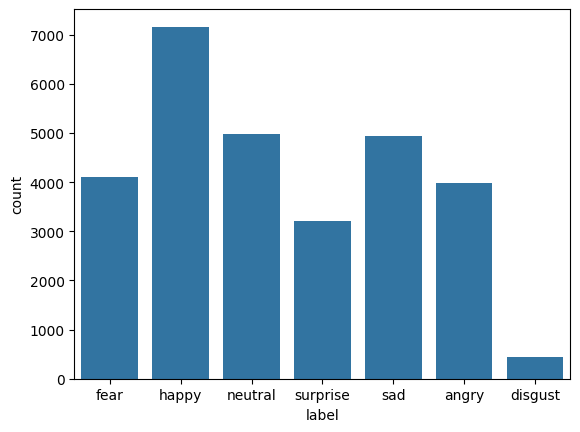

In [7]:
# Plotting frequency of each label
sns.countplot(x = 'label',data=train)
plt.show()

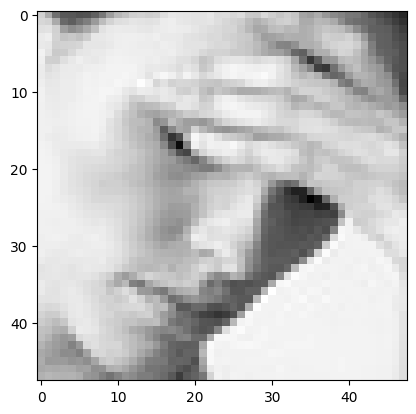

In [8]:
#Viewing Sample Image
from PIL import Image #Pillow Library to open image
img = Image.open(train['image'][0])
plt.imshow(img, cmap='gray')

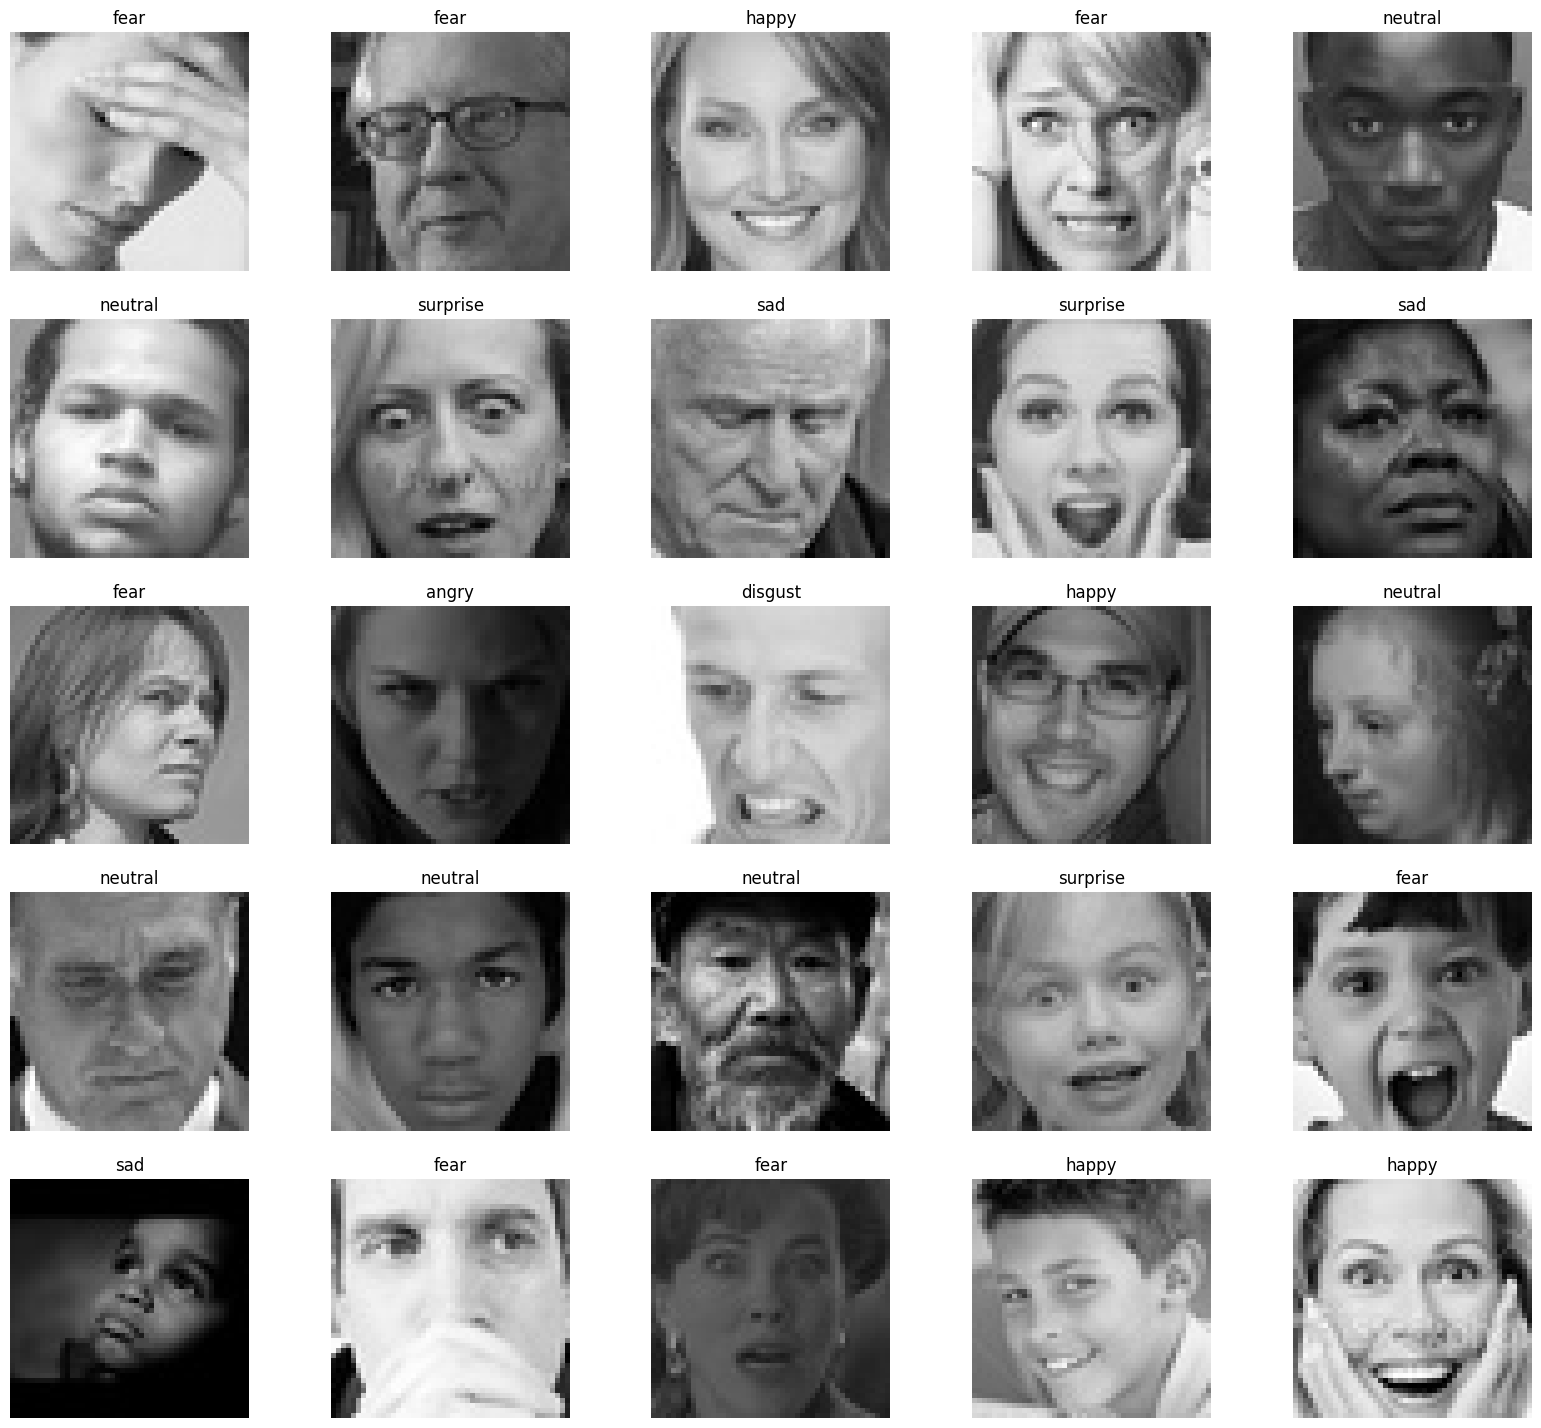

In [9]:
# Displaying a 5X5 grid of first 25 images from training dataset along with their labels
plt.figure(figsize=(20,18))
file = train.iloc[0:25]
for index,file,label in file.itertuples():
  plt.subplot(5,5,index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title(label)
  plt.axis('off')

In [10]:
# Creating a function to extract features from images
def extracting_features(images):
  features = []
  for image in images:
    img = load_img(image, color_mode = 'grayscale')
    # Converting image file path into numpy array
    img = np.array(img)
    features.append(img)
  return np.array(features)

In [11]:
# Feature Extraction for Training Data
training_features = extracting_features(train['image'])

In [12]:
# Feature Extraction for Testing Data
testing_features = extracting_features(test['image'])

In [13]:
#Normalizing the image
x_train = training_features/255.0
x_test = testing_features/255.0

### Encoding Target Labels

The target labels in the 'label' column of the 'train' and 'test' DataFrames are encoded to be suitable for a neural network classification task. This involves two steps: first, label encoding to convert categorical labels into numerical integers, and then one-hot encoding to transform these integers into binary vectors.

In [14]:
# Converting label to integer
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(train['label'])
y_train = encoder.transform(train['label'])
y_test = encoder.transform(test['label'])

# One hot encoding
y_train = to_categorical(y_train, num_classes = 7)
y_test = to_categorical(y_test, num_classes = 7)

In [15]:
y_train[0]

array([0., 0., 1., 0., 0., 0., 0.])

In [16]:
# Expected shape of our input images and no. of output classes
input_shape = (48,48,1)
output_class = 7

In [17]:
# Reshaping:
x_train = x_train.reshape(-1, 48, 48, 1)
x_test = x_test.reshape(-1, 48, 48, 1)

# Model
model = Sequential()

# 1st Block (2 Conv layers)
model.add(Conv2D(64, (3,3), padding='same', input_shape=x_train.shape[1:], kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

# 2nd Block (2 Conv layers)
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

# 3rd Block (2 Conv layers)
model.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

# 4th Block (2 Conv layers)
model.add(Conv2D(512, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(512, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(GlobalAveragePooling2D())

model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(output_class, activation='softmax'))

# Compile
optimizer = Adam(learning_rate=0.001)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience = 8 , restore_best_weights=True)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 256)    │             

 Total params: 4,858,567 (18.53 MB)

 Trainable params: 4,853,959 (18.52 MB)

 Non-trainable params: 4,608 (18.00 KB)

Applying SMOTE to overcome class imbalance. It generates synthetic samples for the minority classes.

In [19]:
# Flattenning the training images to 2D for SMOTE
x_train_flat = x_train.reshape(x_train.shape[0], -1)

# Converting one-hot labels to class labels
y_train_labels = np.argmax(y_train, axis=1)

# Applying SMOTE
smote = SMOTE(random_state=42)
x_smote_flat, y_smote_labels = smote.fit_resample(x_train_flat, y_train_labels)

from collections import Counter
print("After SMOTE:", Counter(y_smote_labels))

# Converting class labels back to one-hot encoding
y_smote = to_categorical(y_smote_labels, num_classes=output_class)

# Reshaping x_smote back to image format
x_smote = x_smote_flat.reshape(-1, 48, 48, 1)

# Defining the Image Data Generator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training the model using .flow()
history = model.fit(
    datagen.flow(x_smote, y_smote, batch_size=128),
    steps_per_epoch=len(x_smote) // 128,
    epochs=60,
    validation_data=(x_test / 255.0, y_test),
    callbacks=[lr_scheduler, early_stopping]
)

After SMOTE: Counter({np.int64(2): 7164, np.int64(3): 7164, np.int64(4): 7164, np.int64(6): 7164, np.int64(5): 7164, np.int64(0): 7164, np.int64(1): 7164})
Epoch 1/60


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 86s 154ms/step - accuracy: 0.1626 - loss: 3.5311 - val_accuracy: 0.0157 - val_loss: 2.5693 - learning_rate: 0.0010
Epoch 2/60
  1/391 ━━━━━━━━━━━━━━━━━━━━ 47s 122ms/step - accuracy: 0.2734 - loss: 2.2761

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2734 - loss: 2.2761 - val_accuracy: 0.0157 - val_loss: 2.5807 - learning_rate: 0.0010
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - accuracy: 0.2603 - loss: 2.1565 - val_accuracy: 0.1721 - val_loss: 4.9940 - learning_rate: 0.0010
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4141 - loss: 1.7253 - val_accuracy: 0.1721 - val_loss: 5.4498 - learning_rate: 0.0010
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.3700 - loss: 1.8022 - val_accuracy: 0.1612 - val_loss: 3.7469 - learning_rate: 2.0000e-04
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4141 - loss: 1.5509 - val_accuracy: 0.1612 - val_loss: 3.8112 - learning_rate: 2.0000e-04
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - accuracy: 0.4298 - loss: 1.6464 - val_accuracy: 0.1359 - val_loss: 2.3077 - learning_rate: 2.0000e-04
Epoch 8/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4531 - loss: 1.

In [20]:
# Model Evaluation
# Predicting class labels
y_pred = np.argmax(model.predict(x_test), axis=1)

# Converting y_test to class labels if one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Generating classification report for our trained model
print(classification_report(y_true, y_pred, target_names=['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']))

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
              precision    recall  f1-score   support

       Angry       0.16      0.51      0.25       960
     Disgust       0.02      0.63      0.03       111
        Fear       0.00      0.00      0.00      1018
       Happy       0.00      0.00      0.00      1825
         Sad       0.00      0.00      0.00      1216
    Surprise       0.33      0.00      0.00      1139
     Neutral       0.00      0.00      0.00       797

    accuracy                           0.08      7066
   macro avg       0.07      0.16      0.04      7066
weighted avg       0.08      0.08      0.03      7066



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training another model using class weights to deal with class imabalance. The majority class receives a lower weight, reducing its influence on the model's decision-making process.

In [21]:
# Flattenning y_train
label_y_train = np.argmax(y_train, axis=1)

# Calculating the weights for the classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_y_train),
    y=label_y_train
)

# Converting to dict format
class_weights_dict = dict(enumerate(class_weights))

# Training the model with class weights
history1 = model.fit(x=x_train, y=y_train, batch_size=128, epochs=60,
                    class_weight=class_weights_dict,
                    validation_data=(x_test, y_test),
                    callbacks=[lr_scheduler, early_stopping])


Epoch 1/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 47s 154ms/step - accuracy: 0.4666 - loss: 1.4410 - val_accuracy: 0.5129 - val_loss: 1.4214 - learning_rate: 1.0000e-06
Epoch 2/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 58s 89ms/step - accuracy: 0.4846 - loss: 1.4077 - val_accuracy: 0.5161 - val_loss: 1.4165 - learning_rate: 1.0000e-06
Epoch 3/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.4964 - loss: 1.3694 - val_accuracy: 0.5300 - val_loss: 1.3768 - learning_rate: 1.0000e-06
Epoch 4/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.4980 - loss: 1.3744 - val_accuracy: 0.5256 - val_loss: 1.3830 - learning_rate: 1.0000e-06
Epoch 5/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.5006 - loss: 1.3697 - val_accuracy: 0.5304 - val_loss: 1.3622 - learning_rate: 1.0000e-06
Epoch 6/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.5026 - loss: 1.3639 - val_accuracy: 0.5334 - val_loss: 1.3530 - learning_rate: 1.0000e-06
Epoch 7/60
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/st

Model Evaluation

In [22]:
# Predicting class labels
y_pred = np.argmax(model.predict(x_test), axis=1)

# Converting y_test to class labels if one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Generating classification report for the trained model
print(classification_report(y_true, y_pred, target_names=['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']))

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

       Angry       0.46      0.46      0.46       960
     Disgust       0.17      0.85      0.29       111
        Fear       0.52      0.12      0.20      1018
       Happy       0.86      0.80      0.83      1825
         Sad       0.50      0.70      0.58      1216
    Surprise       0.48      0.37      0.41      1139
     Neutral       0.64      0.85      0.73       797

    accuracy                           0.58      7066
   macro avg       0.52      0.59      0.50      7066
weighted avg       0.60      0.58      0.56      7066



Training a better CNN model to increase the accuracy.


In [23]:
# Model 2
# Reshaping:
x_train = x_train.reshape(-1, 48, 48, 1)
x_test = x_test.reshape(-1, 48, 48, 1)

# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=10,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train)

# Model
model2 = Sequential()

# 1st Block (2 Conv layers)
model2.add(Conv2D(64, (3,3), padding='same', input_shape=x_train.shape[1:], kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.3))

# 2nd Block (2 Conv layers)
model2.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.5))

# 3rd Block (2 Conv layers)
model2.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.5))

# 4th Block (2 Conv layers)
model2.add(Conv2D(512, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(Conv2D(512, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Activation('relu'))

model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.5))

# Fully connected layers
model2.add(Flatten())

model2.add(Dense(512))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(0.5))

model2.add(Dense(256))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(0.5))

model2.add(Dense(output_class, activation='softmax'))

# Compile
optimizer = Adam(learning_rate=0.0005)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history2 = model2.fit(x=x_train, y=y_train, batch_size=128, epochs=100,
                    validation_data=(x_test, y_test),
                    callbacks=[lr_scheduler, early_stopping])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 50s 152ms/step - accuracy: 0.1975 - loss: 3.7910 - val_accuracy: 0.1612 - val_loss: 3.3180 - learning_rate: 5.0000e-04
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 59s 92ms/step - accuracy: 0.2401 - loss: 3.2428 - val_accuracy: 0.2583 - val_loss: 3.1205 - learning_rate: 5.0000e-04
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.3330 - loss: 2.7776 - val_accuracy: 0.3915 - val_loss: 2.4492 - learning_rate: 5.0000e-04
Epoch 4/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.4113 - loss: 2.3534 - val_accuracy: 0.4356 - val_loss: 2.1385 - learning_rate: 5.0000e-04
Epoch 5/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.4695 - loss: 2.0228 - val_accuracy: 0.4997 - val_loss: 1.8349 - learning_rate: 5.0000e-04
Epoch 6/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5000 - loss: 1.8123 - val_accuracy: 0.5047 - val_loss: 1.7616 - learning_rate: 5.0000e-04
Epoch 7/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 22s 

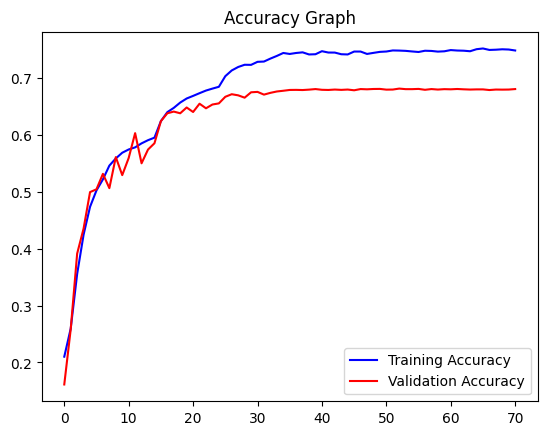

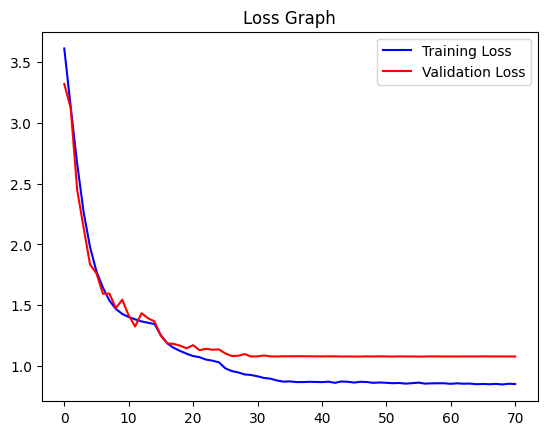

In [24]:
# Plotting accuracy and loss
accuracy = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
epochs = range(len(accuracy))
plt.plot(epochs,accuracy,'b',label='Training Accuracy')
plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history2.history['loss']
val_loss = history2.history['val_loss']
epochs = range(len(loss))
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs,val_loss,'r',label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()


In [25]:
# Predict on test data
y_pred_probs = model2.predict(x_test)  # Probabilities output by softmax
y_pred = np.argmax(y_pred_probs, axis=1)  # Predicted class labels

# If y_test is one-hot encoded, convert it to class labels
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test  # Already class labels

class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
              precision    recall  f1-score   support

       Angry       0.62      0.58      0.60       960
     Disgust       0.66      0.60      0.63       111
        Fear       0.58      0.47      0.52      1018
       Happy       0.86      0.88      0.87      1825
         Sad       0.60      0.69      0.64      1216
    Surprise       0.55      0.56      0.55      1139
     Neutral       0.77      0.80      0.78       797

    accuracy                           0.68      7066
   macro avg       0.66      0.65      0.66      7066
weighted avg       0.68      0.68      0.68      7066



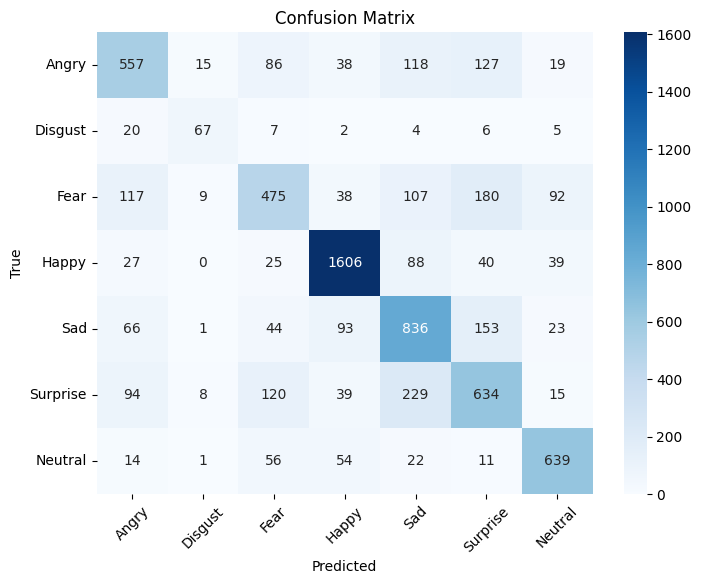

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Assume y_true, y_pred, and class_names are already defined
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45)
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)
plt.show()


In [27]:
# Saving the 2nd model
model2.save('emotion_recognition_model.keras')

Original Output: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Output: fear


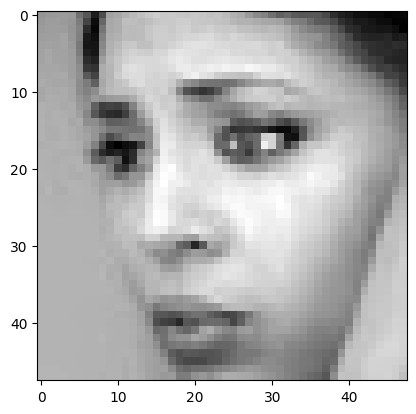

In [28]:
image_index = random.randint(0,len(test))
print('Original Output:',test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

Original Output: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted Output: happy


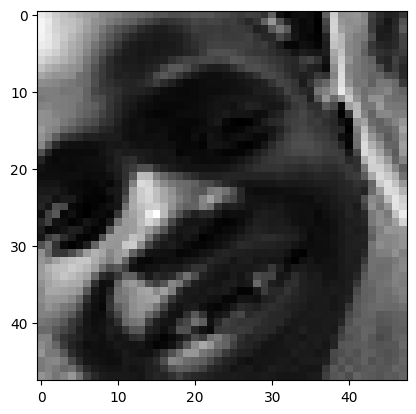

In [68]:
image_index = random.randint(0,len(test))
print('Original Output:', test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

Original Output: surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Output: surprise


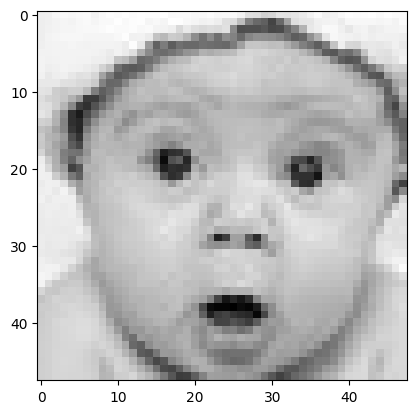

In [67]:
image_index = random.randint(0,len(test))
print('Original Output:', test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

Original Output: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Output: angry


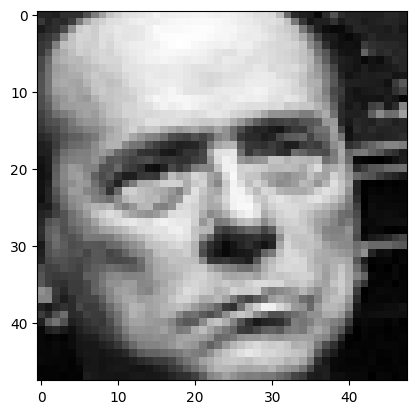

In [69]:
image_index = random.randint(0,len(test))
print('Original Output:', test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

Original Output: angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Output: angry


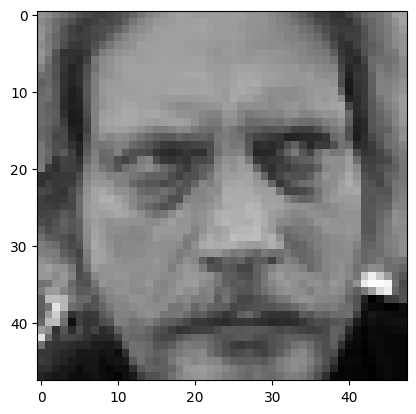

In [70]:
image_index = random.randint(0,len(test))
print('Original Output:', test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

Original Output: angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted Output: happy


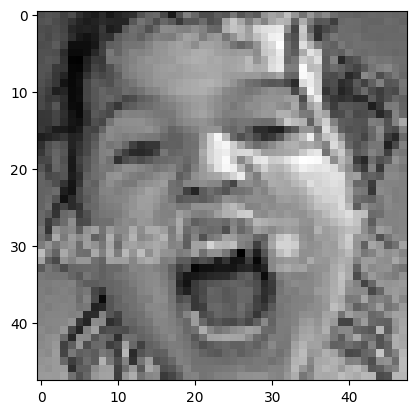

In [73]:
image_index = random.randint(0,len(test))
print('Original Output:', test['label'][image_index])
pred = model2.predict(x_test[image_index].reshape(1,48,48,1))
pred_label = encoder.inverse_transform([pred.argmax()])[0]
print('Predicted Output:', pred_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap = 'gray')

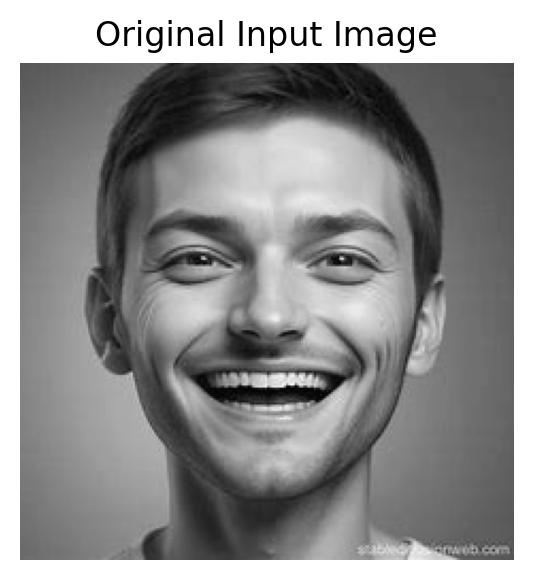

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Emotion: Happy


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image

# Load trained model
model = load_model('emotion_recognition_model.keras')

# Emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Load and display original image
img_path = 'h_im.jpg'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=200)
plt.imshow(original_img, cmap='gray')
plt.title("Original Input Image", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]

# Display result
print(f"Predicted Emotion: {predicted_label}")


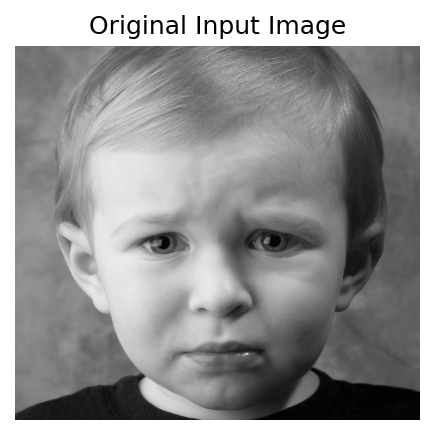

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step
Predicted Emotion: Angry


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image

# Load trained model
model = load_model('emotion_recognition_model.keras')

# Emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Load and display original image
img_path = 's_im.jpeg'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(original_img, cmap='gray')
plt.title("Original Input Image", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]

# Display result
print(f"Predicted Emotion: {predicted_label}")


Emotions like sad and angry often have similar features (e.g., furrowed brows, downturned lips), making them hard for models to distinguish.
Misclassifications (e.g., Sad mispredicted as Angry) highlight the limitations of low-resolution FER-2013 data and the overlap in facial cues.
For future work we can try training on higher-resolution datasets (e.g., AffectNet, RAF-DB)

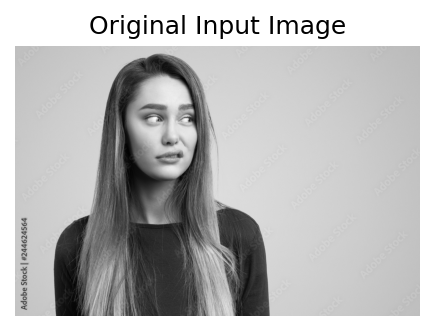

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Emotion: Neutral


In [43]:
# Load and display original image
img_path = 'd_im.jpg'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(original_img, cmap='gray')
plt.title("Original Input Image", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]
print(f"Predicted Emotion: {predicted_label}")


The model occasionally predicts Disgust as Neutral. This can be attributed to the small number of Disgust samples in FER-2013 dataset and the subtle nature of disgust expressions. In low-resolution images (48×48), key visual cues like nose wrinkling are often lost, making it hard for the model to differentiate from Neutral. Improving class balance and input resolution could mitigate this.

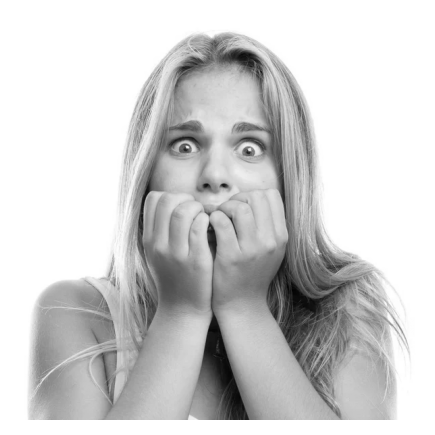

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Emotion: Fear


In [45]:
# Load and display original image
img_path = 'f_im.jpg'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(original_img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]
print(f"Predicted Emotion: {predicted_label}")

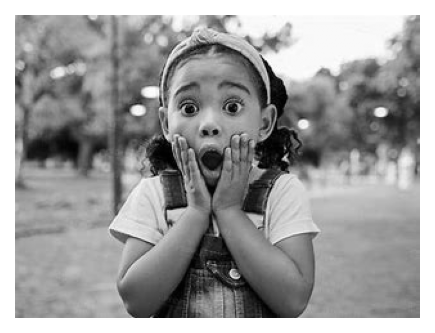

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Emotion: Sad


In [46]:
# Load and display original image
img_path = 'sur_img.jpg'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(original_img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]
print(f"Predicted Emotion: {predicted_label}")


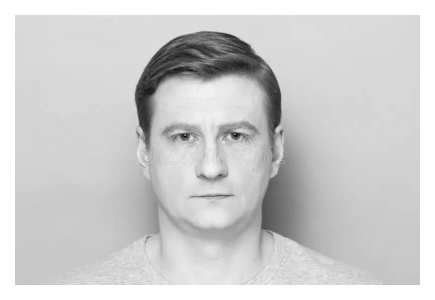

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Emotion: Sad


In [47]:
# Load and display original image
img_path = 'n_im.webp'
original_img = Image.open(img_path).convert('L')  # Convert to grayscale if needed
plt.figure(figsize=(3,3), dpi=150)
plt.imshow(original_img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocess image for prediction
preprocessed_img = original_img.resize((48, 48), resample=Image.LANCZOS)
img_array = image.img_to_array(preprocessed_img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
predicted_label = emotion_labels[predicted_class]
print(f"Predicted Emotion: {predicted_label}")


A face with a relaxed mouth or slight downturn of mouth might look sad — even if the person is neutral.